In [1]:
#라이브러리 호출
import numpy as np
import matplotlib.pyplot as plt
import cv2

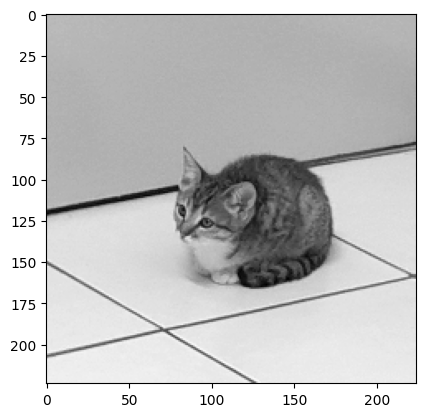

In [2]:
#이미지 불러오기 (흑백)
img = cv2.imread('image.png', cv2.IMREAD_GRAYSCALE)
img = cv2.resize(img, (224, 224)) 
#224x224로 리사이즈 (필터링 결과를 선명하게 보기 위해 사이즈를 줄임임)
plt.imshow(img, cmap="gray")

In [3]:
def gaussian_kernel(k, sigma):
    ax = np.linspace(-(k - 1) / 2., (k - 1) / 2., k)
    xx, yy = np.meshgrid(ax, ax)
    #가우시안 함수 수식
    kernel = np.exp(-(xx**2 + yy**2) / (2. * sigma**2))
    kernel /= np.sum(kernel)
    return kernel

In [4]:
# FFT 기반 컨벌루션 함수
# 컨볼루션은 많은 연산이 필요하기 때문에 푸리에 변환을 이용용
# 이미지, 커널을 전부 푸리에 변환으로 주파수 영역으로 바꿈
# 이후, 주파수 영역에서의 곱샘 진행
# 역 푸리에 변환 
def fft_convolution(img, kernel):
    H, W = img.shape
    KH, KW = kernel.shape

    # 이미지와 커널을 zero-padding, 선형 컨벌루션을 위함함
    pad_H = H + KH - 1
    pad_W = W + KW - 1

    padded_img = np.zeros((pad_H, pad_W)) #0으로 채워진 이미지 생성
    padded_img[:H, :W] = img # 원본 이미지 삽입

    padded_kernel = np.zeros((pad_H, pad_W))
    padded_kernel[:KH, :KW] = kernel
    # 이미지와 커널이 같은 크기로 만들어야 주파수 영역에서 곱셈 가능

    # FFT 수행 (중심 이동 포함)
    fft_img = np.fft.fftshift(np.fft.fft2(padded_img)) #2차원 푸리에 변환
    fft_kernel = np.fft.fftshift(np.fft.fft2(padded_kernel)) #주파수의 중심을 중앙으로 이동동

    # 주파수 영역에서 곱하기
    fft_product = fft_img * fft_kernel

    # 역 FFT 수행
    ifft_shift = np.fft.ifftshift(fft_product) #주파수의 중심을 원래 위치로 이동
    conv_result = np.fft.ifft2(ifft_shift) #2차원 역 푸리에 변환
    conv_result = np.real(conv_result) #실수부만 추출(소수점 오차로 인한 복소수 제거)

    start_H = KH // 2 # 필터로 인해 생긴 여백 제거
    start_W = KW // 2
    result = conv_result[start_H:start_H + H, start_W:start_W + W]

    return result


In [5]:
# 커널 크기 리스트
kernel_size = 5
sigma_values = [1.0, 2.0, 3.0, 4.0]

(np.float64(-0.5), np.float64(223.5), np.float64(223.5), np.float64(-0.5))

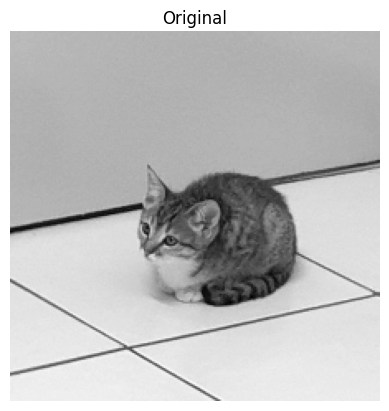

In [6]:
plt.imshow(img, cmap='gray')
plt.title("Original")
plt.axis('off')

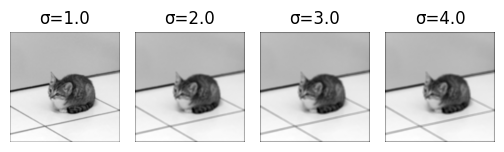

In [7]:
for idx, sigma in enumerate(sigma_values):
    kernel = gaussian_kernel(kernel_size, sigma)
    filtered_img = fft_convolution(img, kernel)

    plt.subplot(1, len(sigma_values) + 1, idx + 2)
    plt.imshow(filtered_img, cmap='gray')
    plt.title(f"σ={sigma}")
    plt.axis('off')

plt.tight_layout()
plt.show()